In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 


# Loading the dataset 

In [2]:
data = pd.read_csv(r'C:\Users\dell\OneDrive\Desktop\MAY TEKWORK\Stacking classification\credit_data.csv')
data.head()

,clientid,income,age,loan,default
0,1,66155.92510,59.017015,8106.532131,0
1,2,34415.15397,48.117153,6564.745018,0
2,3,57317.17006,63.108049,8020.953296,0
3,4,42709.53420,45.751972,6103.642260,0
4,5,66952.68885,18.584336,8770.099235,1


# Checking if their is null value and outliers 

In [3]:
# Checking for null values
data.isnull().sum()


clientid    0
income      0
age         3
loan        0
default     0
dtype: int64

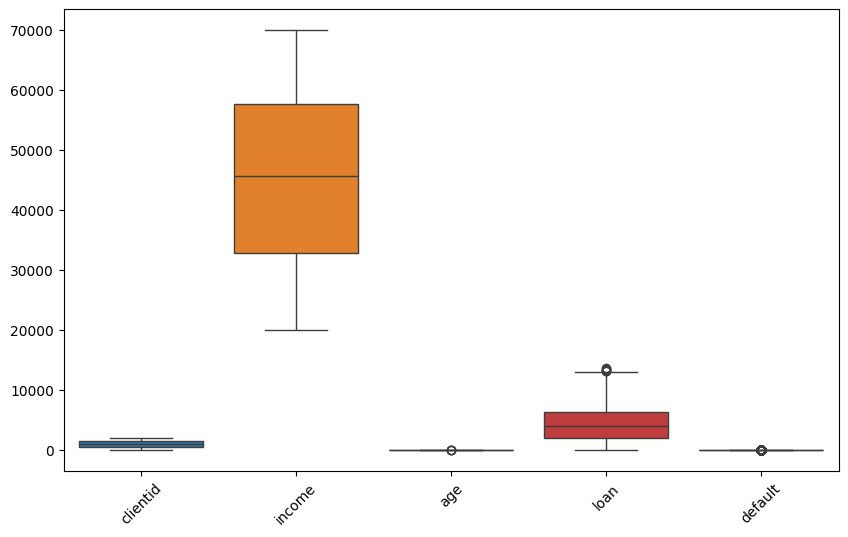

In [4]:
# checking for outliers 
plt.figure(figsize=(10,6))
sns.boxplot(data=data)
plt.xticks(rotation=45)
plt.show()


# Encodeing 

In [5]:
# feature Engineering
data['income'] = data['income'].fillna(data['income'].median())
data['age'] = data['age'].fillna(data['age'].median())
data['loan'] = data['loan'].fillna(data['loan'].median())
data.isnull().sum()

clientid    0
income      0
age         0
loan        0
default     0
dtype: int64

In [6]:
# Train test split
from sklearn.model_selection import train_test_split
X = data.drop('default', axis=1)
y = data['default']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [7]:
# training the model stacking classifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
estimators = [
    ('lr', LogisticRegression()),
    ('dt', DecisionTreeClassifier()),
    ('svc', SVC(probability=True)),
    ('rf', RandomForestClassifier())
]
stacking_clf = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
stacking_clf.fit(X_train, y_train)

c:\Users\dell\anaconda3\envs\myenv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\dell\anaconda3\envs\myenv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing

,estimators,"[('lr', ...), ('dt', ...), ...]"
,final_estimator,LogisticRegression()
,cv,None
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [8]:
# Prediction and evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
y_pred = stacking_clf.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       330
           1       1.00      0.91      0.96        70

    accuracy                           0.98       400
   macro avg       0.99      0.96      0.97       400
weighted avg       0.99      0.98      0.98       400

Confusion Matrix:
 [[330   0]
 [  6  64]]
Accuracy Score: 0.985


In [9]:
# creating a new dataframe to compare actual and predicted values
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(comparison_df.head(10))


      Actual  Predicted
1860       1          1
353        1          1
1333       0          0
905        0          0
1289       0          0
1273       0          0
938        0          0
1731       1          1
65         0          0
1323       0          0


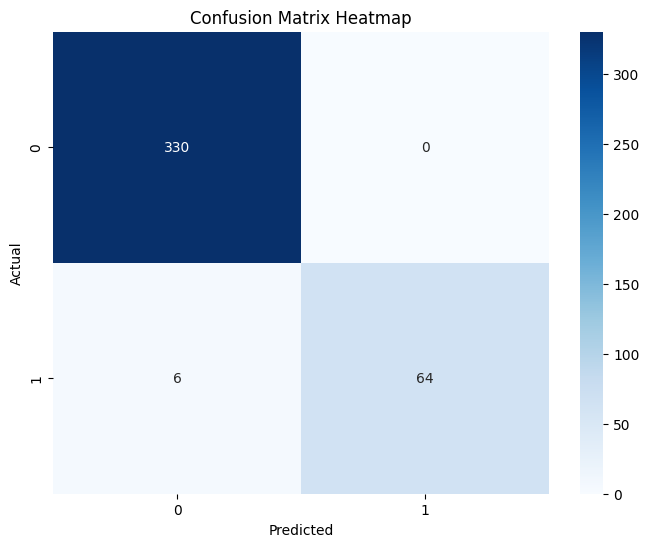

In [10]:
# Creating a heatmap for the confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()